## 가설 설정 배경
> 본격적인 가설 검증 전, **왜 이 가설을 세웠는지**를 데이터로 확인합니다.

| 단계 | 내용 |
|------|------|
| Step 1 | 데이터 기본 현황 파악 | 
| Step 2 | 스페셜 매장 분리 근거 | 
| Step 3 | 리뷰 수 분포 확인 | 
| Step 4 | 전체 키워드 분포 확인 | 

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
from scipy.stats import spearmanr
import platform

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [25]:
# 1. 경로 설정 
info_path = r'C:\Users\cki68\OneDrive\바탕 화면\workspace\파이널 프로젝트\멋사 Final_Project_env\data\store_info.csv'
review_path = r'C:\Users\cki68\OneDrive\바탕 화면\workspace\파이널 프로젝트\멋사 Final_Project_env\data\store_review_summary.csv'

# 2. 파일을 안전하게 읽어오는 함수 정의 
def load_csv_safely(path):
    # 파일명만 따로 추출 (f-string 내 백슬래시 오류 방지)
    file_name = os.path.basename(path)
    
    # 인코딩 시도
    for enc in ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"성공: {file_name}를 '{enc}' 인코딩으로 읽었습니다.")
            return df
        except UnicodeDecodeError:
            continue
    return None

In [26]:
# 3. 데이터 로드
store_info = load_csv_safely(info_path)
store_review_summary = load_csv_safely(review_path)

성공: store_info.csv를 'utf-8-sig' 인코딩으로 읽었습니다.
성공: store_review_summary.csv를 'cp949' 인코딩으로 읽었습니다.


In [27]:
# 데이터 병합
# store_id를 기준 store_info랑 store_review_summary 합침
# store_info에서 store_id와 store_type 컬럼을 가져옴
merged_df = pd.merge(store_review_summary, store_info[['store_id', 'store_type']], on='store_id')

merged_df.head(5)

,store_name,store_id,visitor_review_count,blog_review_count,coffee_tasty,service_kind,beverage_tatsy,dessert_tasty,store_clean,conv_good,...,alcohol_variety,solos_alcohol_good,good_for_special,outdoor_space_good,books_variety,concept_unique,good_for_gifts,course_meal_good,free_snack_good,store_type
0,역삼아레나빌딩,1509,3163,91,1029,421,388,343,282,162,...,0,0,0,0,0,0,0,0,0,일반 매장
1,논현역사거리,1434,4870,198,1530,591,661,524,458,372,...,0,0,0,0,0,0,0,0,0,일반 매장
2,신사역성일빌딩,1595,4359,106,1236,661,534,404,460,331,...,0,0,0,0,0,0,0,0,0,일반 매장
3,국기원사거리,1527,4668,192,1459,658,633,486,440,300,...,0,0,0,0,0,1,1,0,0,일반 매장
4,대치재경빌딩,1468,3604,154,1079,391,424,347,267,252,...,0,0,0,0,0,0,0,0,0,일반 매장


=== STEP 1. 일반 vs 리저브 리뷰 수 격차 ===
일반 매장 총 리뷰 수: 6,990,222건
리저브 매장 총 리뷰 수: 342,785건
→ 일반 매장이 리저브 매장보다 약 20배 많음
→ 절대값 비교 불가 : 각 그룹 내 키워드 비중(%)으로 비교해야 함


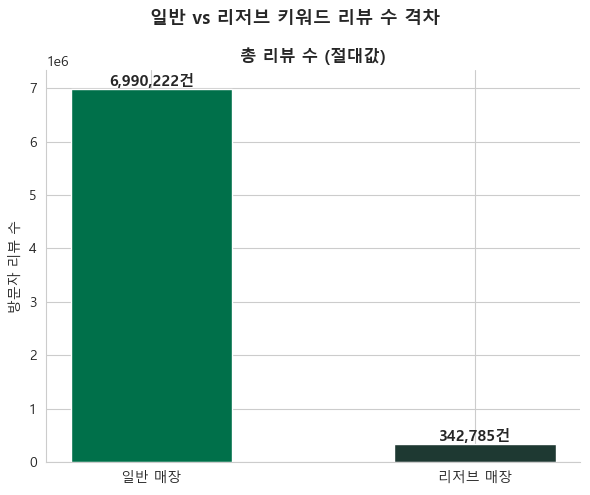

In [28]:
# ── STEP 1: 리뷰 수 격차 확인 → 비중 비교 채택 근거 ──
print('=== STEP 1. 일반 vs 리저브 리뷰 수 격차 ===')

# 스페셜 매장 제외 전의 전체 데이터(merged_df)를 사용하여 리뷰 수 격차 확인
gen_sub = merged_df[merged_df['store_type'] == '일반 매장']
res_sub = merged_df[merged_df['store_type'] == '리저브 매장']

gen_total_review = gen_sub['visitor_review_count'].sum()
res_total_review = res_sub['visitor_review_count'].sum()
ratio = gen_total_review / res_total_review

print(f'일반 매장 총 리뷰 수: {gen_total_review:,}건')
print(f'리저브 매장 총 리뷰 수: {res_total_review:,}건')
print(f'→ 일반 매장이 리저브 매장보다 약 {ratio:.0f}배 많음')
print('→ 절대값 비교 불가 : 각 그룹 내 키워드 비중(%)으로 비교해야 함')

# 그래프 생성
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

plt.bar(['일반 매장', '리저브 매장'],
        [gen_total_review, res_total_review],
        color=['#00704A', '#1E3932'],
        width=0.5)

for val, x in zip([gen_total_review, res_total_review], [0, 1]):
    plt.text(x, val + 50000, f'{val:,}건',
             ha='center', fontsize=11, fontweight='bold')

plt.title('총 리뷰 수 (절대값)', fontsize=12, fontweight='bold')
plt.ylabel('방문자 리뷰 수')

sns.despine()

plt.suptitle(
    f'일반 vs 리저브 키워드 리뷰 수 격차',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.show()

=== STEP 2. 전체 리뷰 키워드 비중 분포 ===
TOP5 키워드 누적 비중: 69.8%
→ 소비자 언급의 절반 이상이 5개 키워드에 집중 → TOP5를 핵심 지표로 설정


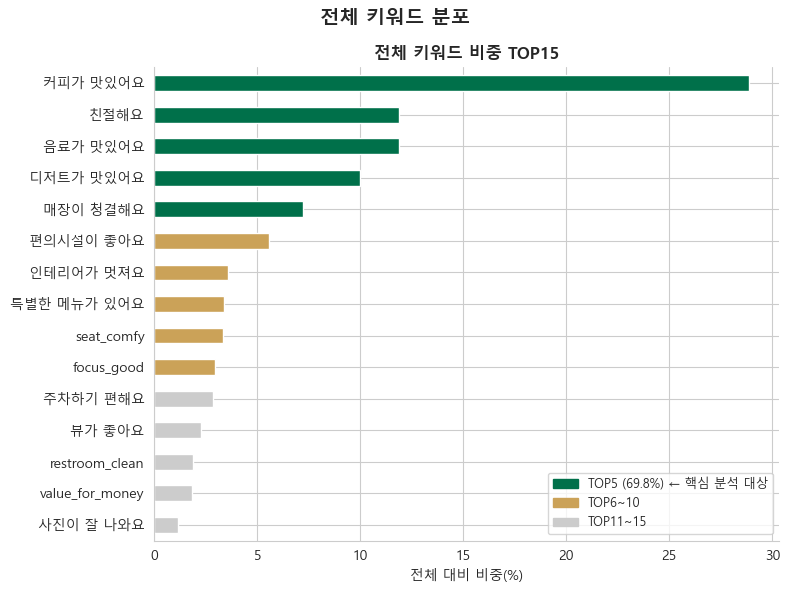

In [29]:
# ── STEP 2: 전체 리뷰 키워드 분포 → TOP5 컷오프 근거 ──
print('=== STEP 2. 전체 리뷰 키워드 비중 분포 ===')

# 1. 키워드 한글 매핑 딕셔너리 및 컬럼 추출
kw_kr = {
    'coffee_tasty': '커피가 맛있어요', 'service_kind': '친절해요',
    'beverage_tatsy': '음료가 맛있어요', 'dessert_tasty': '디저트가 맛있어요',
    'store_clean': '매장이 청결해요', 'interior_good': '인테리어가 멋져요',
    'view_good': '뷰가 좋아요', 'photo_good': '사진이 잘 나와요',
    'parking_easy': '주차하기 편해요', 'conv_good': '편의시설이 좋아요',
    'store_spacious': '매장이 넓어요', 'special_menu': '특별한 메뉴가 있어요'
}

exclude_cols = ['store_name', 'store_id', 'visitor_review_count', 'blog_review_count', 'store_type']
keyword_cols = [c for c in merged_df.columns if c not in exclude_cols]

# 2. 비중 계산
all_sums   = merged_df[keyword_cols].sum().sort_values(ascending=False)
all_total  = all_sums.sum()
all_ratios = (all_sums / all_total * 100).round(2)
top5_share = all_ratios.head(5).sum()

print(f'TOP5 키워드 누적 비중: {top5_share:.1f}%')
print('→ 소비자 언급의 절반 이상이 5개 키워드에 집중 → TOP5를 핵심 지표로 설정')

# 3. 시각화
fig, ax1 = plt.subplots(figsize=(8, 6)) 

# TOP15 가로 막대
top15 = all_ratios.head(15).copy()
top15.index = [kw_kr.get(k, k) for k in top15.index]
colors_15 = ['#00704A'] * 5 + ['#CBA258'] * 5 + ['#cccccc'] * 5

top15[::-1].plot(kind='barh', ax=ax1, color=colors_15[::-1])

ax1.set_title('전체 키워드 비중 TOP15', fontsize=12, fontweight='bold')
ax1.set_xlabel('전체 대비 비중(%)')

from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color='#00704A', label=f'TOP5 ({top5_share:.1f}%) ← 핵심 분석 대상'),
    Patch(color='#CBA258', label='TOP6~10'),
    Patch(color='#cccccc', label='TOP11~15')
], fontsize=9)

sns.despine(ax=ax1)

plt.suptitle('전체 키워드 분포', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# -------------------------------------------------------
# [추가] 전체 매장 통합: 키워드 비중 TOP 15 데이터 추출
# -------------------------------------------------------

# 1. 키워드 한글 매핑 (데이터에 맞게 확인 필요)
kw_kr = {
    'coffee_tasty': '커피가 맛있어요', 'service_kind': '친절해요',
    'beverage_tatsy': '음료가 맛있어요', 'dessert_tasty': '디저트가 맛있어요',
    'store_clean': '매장이 청결해요', 'interior_good': '인테리어가 멋져요',
    'view_good': '뷰가 좋아요', 'photo_good': '사진이 잘 나와요',
    'parking_easy': '주차하기 편해요', 'conv_good': '대화하기 좋아요',
    'store_spacious': '매장이 넓어요', 'special_menu': '특별한 메뉴가 있어요',
    'restroom_clean': '화장실이 깨끗해요', 'seat_comfy': '좌석이 편해요',
    'quiet_store': '조용해요', 'focus_good': '집중하기 좋아요'
}

# 2. 키워드 컬럼만 추출 (merged_df 기준)
keyword_cols = [c for c in merged_df.columns if c in kw_kr.keys()]

# 3. 전체 매장의 키워드별 합계 계산 및 상위 15개 추출
all_sums = merged_df[keyword_cols].sum().sort_values(ascending=False)
top15_all = all_sums.head(15)

# 4. 전체 언급량 중 각 키워드의 비중(%) 계산
total_mentions = all_sums.sum()
top15_ratios = (top15_all / total_mentions * 100).round(2)

# 5. 결과 데이터프레임 생성
miricanvas_total_data = pd.DataFrame({
    '순위': range(1, 16),
    '키워드': [kw_kr.get(k, k) for k in top15_ratios.index],
    '전체 비중(%)': top15_ratios.values
})

display(miricanvas_total_data)

,순위,키워드,전체 비중(%)
0,1,커피가 맛있어요,29.71
1,2,친절해요,12.20
2,3,음료가 맛있어요,12.20
3,4,디저트가 맛있어요,10.27
4,5,매장이 청결해요,7.45
5,6,대화하기 좋아요,5.71
6,7,인테리어가 멋져요,3.69
7,8,특별한 메뉴가 있어요,3.47
8,9,좌석이 편해요,3.43
9,10,집중하기 좋아요,3.01


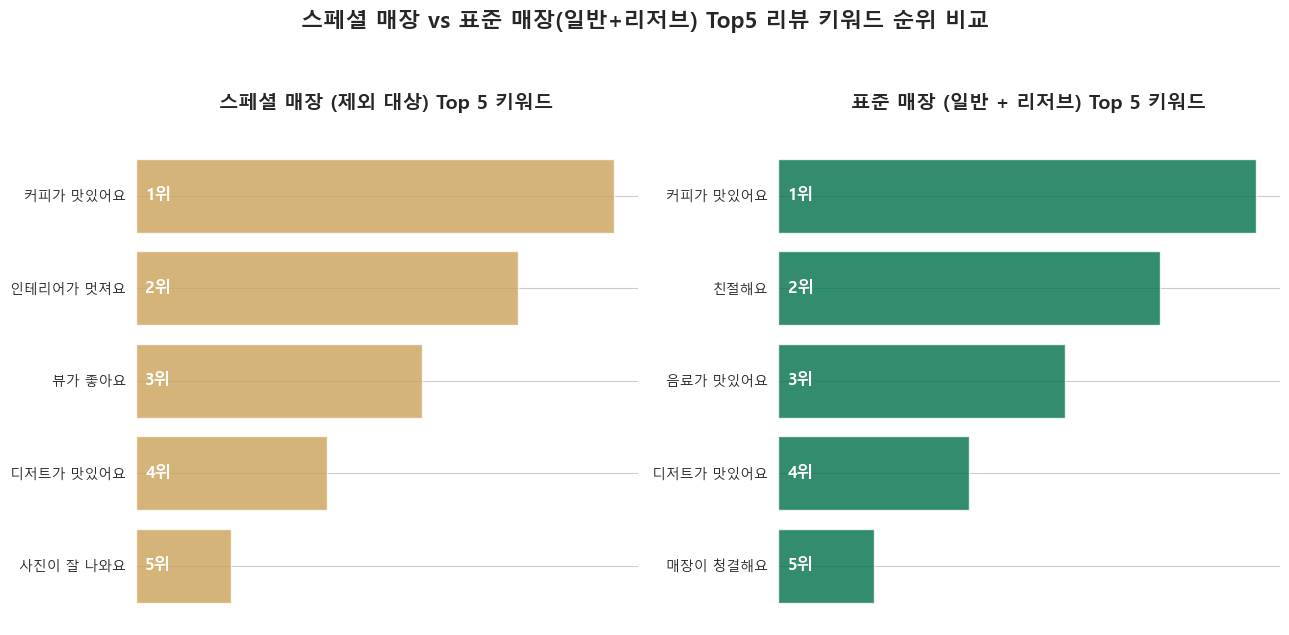

In [31]:
# ── STEP 3: 스페셜 매장 제외 근거  ──

# 1. 스페셜 매장 리스트 정의 및 그룹화
special_stores = [
    '광장마켓', '더여수돌산DT', '경동1960', '이대', '장충라운지R',
    '대구종로고택', '더북한산', '더북한강R', '더양평DT',
    '더춘천의암호R', '더제주송당파크R', '가나아트파크'
]
merged_df['is_special'] = merged_df['store_name'].isin(special_stores)

# 일반/리저브를 하나로 묶어 '표준 매장' 그룹 생성 (뒤의 가설 분석 보호)
merged_df['analysis_group'] = merged_df.apply(
    lambda x: '스페셜 매장' if x['is_special'] else '표준 매장 (일반/리저브)', axis=1
)

# 2. Top 5 키워드 순위 추출 함수
def get_top5_list(df):
    sums = df[keyword_cols].sum()
    top5 = sums.nlargest(5)
    return [kw_kr.get(k, k) for k in top5.index]

special_top5 = get_top5_list(merged_df[merged_df['analysis_group'] == '스페셜 매장'])
standard_top5 = get_top5_list(merged_df[merged_df['analysis_group'] == '표준 매장 (일반/리저브)'])

# 3. 시각화 (1위가 최상단에 오는 순위형 막대 그래프)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
groups = [special_top5, standard_top5]
titles = ['스페셜 매장 (제외 대상)', '표준 매장 (일반 + 리저브)']
colors = ['#CBA258', '#00704A'] # 골드와 스타벅스 그린

for ax, ranks, title, color in zip(axes, groups, titles, colors):
    display_ranks = ranks[::-1]
    widths = range(1, 6) 
    
    ax.barh(display_ranks, widths, color=color, alpha=0.8)
    
    # "n위" 라벨 표시
    for i in range(5):
        rank_num = 5 - i
        ax.text(0.1, i, f'{rank_num}위', va='center', color='white', fontweight='bold', fontsize=12)
    
    ax.set_title(f'{title} Top 5 키워드', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks([]) # 수치 데이터 숨김
    sns.despine(left=True, bottom=True, ax=ax)

plt.suptitle('스페셜 매장 vs 표준 매장(일반+리저브) Top5 리뷰 키워드 순위 비교', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 종합 결론

| 탐색 내용 | 발견 | 분석 결정 |
|-----------|------|----------|
| 매장 유형 분포 | 일반 2,042개 / 리저브 59개 / 스페셜 12개 | 세 그룹 분리 필요 |
| 스페셜 매장 키워드 | 뷰/분위기 키워드 상위 → 다른 패턴 | 스페셜 매장 **제외** |
| 리뷰 수 격차 | 일반이 리저브보다 약 21배 많음 | 절대값 아닌 **비중(%)** 비교 |
| 키워드 집중도 | TOP5가 전체의 약 70% 차지 | **TOP5 중심** 비교 |

> **(H02-1) 매장 유형에 따른 핵심 리뷰 키워드 비중은 유의미한 차이가 없을 것이다.**

---

### (H02-1) 매장 유형(일반/리저브)에 따른 핵심 리뷰 키워드 비중은 유의미한 차이가 없을 것이다. 
- 단, 스페셜 매장 제외

In [32]:
# 스페셜 매장 리스트 정의 및 제외 (필터링)
# 인테리어나 뷰가 특화된 매장들은 '노이즈'로 간주하여 분석에서 제외합니다.
special_stores = [
    '광장마켓', '더여수돌산DT', '경동1960', '이대', '장충라운지R', 
    '대구종로고택', '더북한산', '더북한강R', '더양평DT', 
    '더춘천의암호R', '더제주송당파크R', '가나아트파크'
]

# store_name이 리스트에 포함되지 않은 매장들만 추출
filtered_df = merged_df[~merged_df['store_name'].isin(special_stores)]


In [33]:
# 매장 유형별 개수 확인
# 스페셜 매장 필터링 후, 분석에 사용된 순수 일반/리저브 매장 수를 출력합니다.
store_counts = filtered_df['store_type'].value_counts()
print("--- 분석 대상 매장 수 확인 ---")
print(f"일반 매장: {store_counts.get('일반 매장', 0)}개")
print(f"리저브 매장: {store_counts.get('리저브 매장', 0)}개")
print("-" * 40)

--- 분석 대상 매장 수 확인 ---
일반 매장: 2042개
리저브 매장: 59개
----------------------------------------


In [34]:
# 3. 분석 대상 키워드 컬럼 리스트 만들기
exclude_cols = ['store_name', 'store_id', 'visitor_review_count', 'blog_review_count', 'store_type']
keyword_cols = [col for col in filtered_df.columns 
                if col not in exclude_cols and pd.api.types.is_numeric_dtype(filtered_df[col])]

In [35]:
# 4. [일반 매장 분석]
# 일반 매장 데이터를 따로 모으고 각 키워드의 합계를 구합니다.
gen_subset = filtered_df[filtered_df['store_type'] == '일반 매장']
gen_keyword_sums = gen_subset[keyword_cols].sum()
gen_total_mentions = gen_keyword_sums.sum() # 일반 매장 전체 키워드 언급 총합

# (1) TOP 5 먼저 뽑기
gen_top5 = gen_keyword_sums.sort_values(ascending=False).head(5)
# (2) 비중(%) 계산하기
gen_top5_ratios = (gen_top5 / gen_total_mentions) * 100

gen_top5


coffee_tasty      2423633
service_kind       997722
beverage_tatsy     995621
dessert_tasty      836478
store_clean        606432
dtype: int64

In [36]:
# 5. [리저브 매장 분석]
# 리저브 매장 데이터를 따로 모으고 각 키워드의 합계를 구합니다.
res_subset = filtered_df[filtered_df['store_type'] == '리저브 매장']
res_keyword_sums = res_subset[keyword_cols].sum()
res_total_mentions = res_keyword_sums.sum() # 리저브 매장 전체 키워드 언급 총합

# (1) TOP 5 먼저 뽑기
res_top5 = res_keyword_sums.sort_values(ascending=False).head(5)
# (2) 비중(%) 계산하기
res_top5_ratios = (res_top5 / res_total_mentions) * 100

res_top5

coffee_tasty      114987
beverage_tatsy     46852
service_kind       46671
dessert_tasty      37725
store_clean        29816
dtype: int64

In [37]:
# 6. 결과 비교표 생성을 위한 한글 변환 사전
keyword_kr = {
    'coffee_tasty': '커피가 맛있어요', 'service_kind': '친절해요', 
    'beverage_tatsy': '음료가 맛있어요', 'dessert_tasty': '디저트가 맛있어요', 
    'store_clean': '매장이 청결해요'
}

# 7. 항목별 1:1 비중 비교 데이터프레임 생성
comparison_data = []
for kw in gen_top5.index:
    gen_ratio = (gen_keyword_sums[kw] / gen_total_mentions) * 100
    res_ratio = (res_keyword_sums[kw] / res_total_mentions) * 100
    comparison_data.append({
        '핵심 리뷰 키워드': keyword_kr.get(kw, kw),
        '일반 매장 비중(%)': round(gen_ratio, 2),
        '리저브 매장 비중(%)': round(res_ratio, 2),
        '비중 차이(%p)': round(abs(gen_ratio - res_ratio), 2)  # abs()로 절대값 처리
    })

comparison_df = pd.DataFrame(comparison_data)

print("[ TOP5 키워드 비중 비교 ]")
display(comparison_df)


[ TOP5 키워드 비중 비교 ]


,핵심 리뷰 키워드,일반 매장 비중(%),리저브 매장 비중(%),비중 차이(%p)
0,커피가 맛있어요,29.05,28.11,0.94
1,친절해요,11.96,11.41,0.55
2,음료가 맛있어요,11.93,11.45,0.48
3,디저트가 맛있어요,10.03,9.22,0.80
4,매장이 청결해요,7.27,7.29,0.02


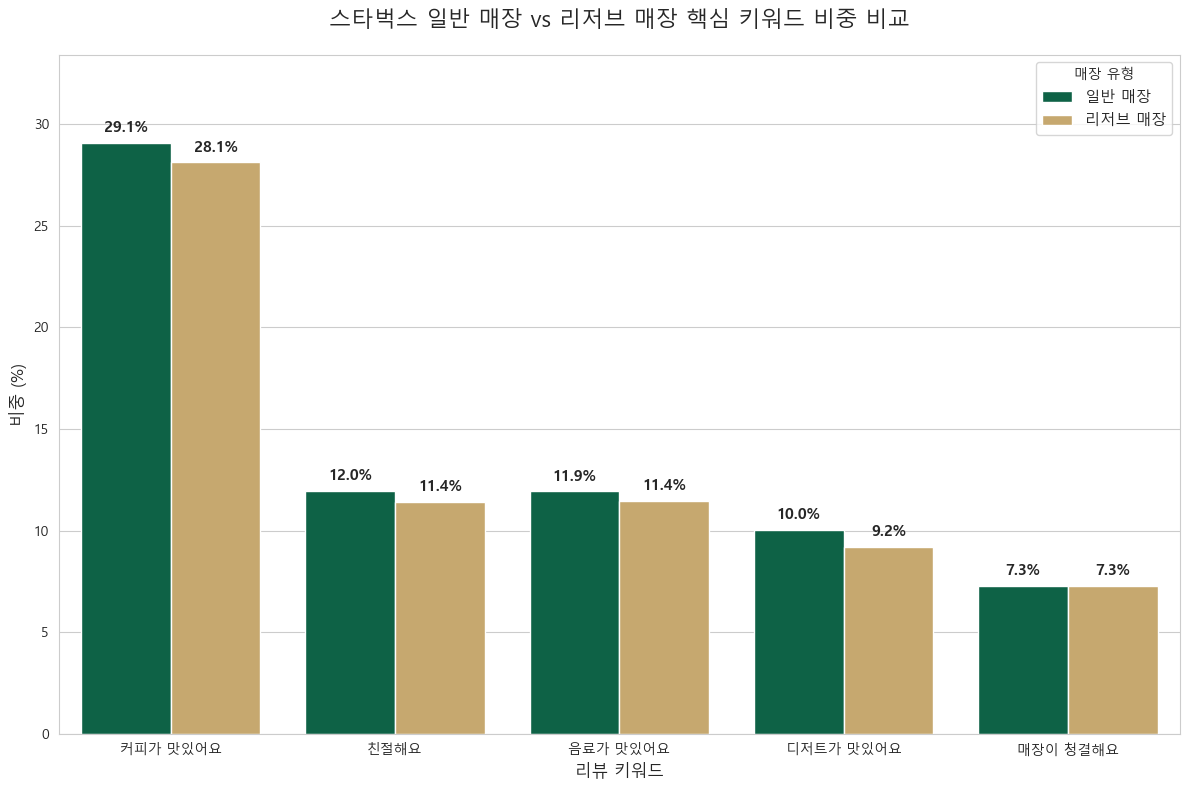

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화 스타일과 테마를 먼저 설정 (폰트 설정보다 먼저 와야 합니다)
sns.set_style("whitegrid")

# 2. [윈도우 전용] 한글 폰트 강제 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 3. 데이터 변환 (기존 comparison_df 활용)
plot_df = comparison_df.melt(id_vars='핵심 리뷰 키워드', 
                             value_vars=['일반 매장 비중(%)', '리저브 매장 비중(%)'],
                             var_name='매장 유형', 
                             value_name='비중(%)')

plot_df['매장 유형'] = plot_df['매장 유형'].str.replace(' 비중(%)', '', regex=False)

# 4. 그래프 생성
plt.figure(figsize=(12, 8))

# 스타벅스 색상 적용
ax = sns.barplot(data=plot_df, x='핵심 리뷰 키워드', y='비중(%)', hue='매장 유형', palette=["#00704A", "#D4AD60"])

# 5. 그래프 꾸미기
plt.title('스타벅스 일반 매장 vs 리저브 매장 핵심 키워드 비중 비교', fontsize=16, pad=20)
plt.ylabel('비중 (%)', fontsize=12)
plt.xlabel('리뷰 키워드', fontsize=12)
plt.ylim(0, max(plot_df['비중(%)']) * 1.15)
plt.legend(title='매장 유형', fontsize=11)

# 6. [요청사항] 막대 상단 끝(edge)에만 수치 표시
# label_type='edge'를 쓰면 막대 중간이나 하단에 숫자가 남지 않고 꼭대기에만 붙습니다.
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold', fontsize=11, label_type='edge')

plt.tight_layout()
plt.show()

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 결과를 담을 리스트 초기화
stats_results = []

# 기존 분석에서 사용한 TOP 5 키워드에 대해 반복
for kw in gen_top5.index:
    # 2x2 교차표(Contingency Table) 생성
    observed = np.array([
        [gen_keyword_sums[kw], res_keyword_sums[kw]],
        [gen_total_mentions - gen_keyword_sums[kw], res_total_mentions - res_keyword_sums[kw]]
    ])
    
    # 카이제곱 검정 수행
    chi2, pval, dof, expected = chi2_contingency(observed)
    
    # 효과 크기(Cramér's V) 계산
    n = observed.sum()
    cramers_v = np.sqrt(chi2 / n)
    
    # 결과 저장 (P-VALUE 포맷을 .4f로 변경하여 소수점 형태로 출력)
    stats_results.append({
        '핵심 키워드': keyword_kr.get(kw, kw),
        'P-VALUE': f"{pval:.4f}",  # e 없이 소수점 4자리까지 표시
        '효과 크기 (Cramér\'s V)': f"{cramers_v:.4f}",
        '해석': '무시할 수준' if cramers_v < 0.1 else '작은 효과'
    })

# 데이터프레임으로 변환 및 출력
stats_df = pd.DataFrame(stats_results)

print("\n" + "="*70)
print(" [가설 2-1 통계 검증] P-VALUE 및 효과 크기 분석 결과")
print("="*70)
print(stats_df.to_string(index=False))
print("="*70)
print(" * P-VALUE가 0.0000으로 나온다면 실제 값이 매우 작아 소수점 4자리 아래에 있다는 뜻입니다.")


 [가설 2-1 통계 검증] P-VALUE 및 효과 크기 분석 결과
   핵심 키워드 P-VALUE 효과 크기 (Cramér's V)     해석
 커피가 맛있어요  0.0000             0.0044 무시할 수준
     친절해요  0.0000             0.0036 무시할 수준
 음료가 맛있어요  0.0000             0.0031 무시할 수준
디저트가 맛있어요  0.0000             0.0057 무시할 수준
 매장이 청결해요  0.6326             0.0002 무시할 수준
 * P-VALUE가 0.0000으로 나온다면 실제 값이 매우 작아 소수점 4자리 아래에 있다는 뜻입니다.


### 결론 1
- 각 매장에서의 상위 5개 키워드 항목이 일치
- 핵심 키워드 5개 항목 모두에서 비중 차이가 1%p 미만으로 나타나, 두 그룹 간의 리뷰 패턴이 매우 균질함을 확인 가능
- 카이제곱 검정상 P-value는 낮게 나타났으나, 이는 방대한 데이터 양에 의한 결과일 뿐 효과 크기 분석을 통해 실질적인 차이가 '무시할 수준'임을 증명함.
- 따라서, 매장 유형(일반/리저브)에 따른 핵심 리뷰 키워드 비중은 유의미한 차이가 없다.

### 
- 우연히 상위 5개만 비슷한 것이라고 의문이 들 수 있음
- 그래서 전체 키워드의 순위 구조를 분석하는 스피어만 상관 분석을 추가로 실시

In [40]:
# 스피어만 상관 분석 : 두 집단의 순위가 얼마나 일치하는가를 측정하는 방법
# 리뷰 개수를 순위로 변환해 비교하기 때문에, 매장 수가 압도적으로 차이가 남에도 불구하고 두 집단을 평등하게 비교 가능
# 데이터가 한쪽으로 치우쳐 있어도 상관없는 비모수적 방법 : 실제 값의 크기보다는 그 값이 차지하는 순서만 보기 때문에 통계적 오류가 적음
# 즉, 집단 간 크기 차이가 크고, 데이터가 편향되어 있어 '순위'를 비교하는 것이 본질적인 고객 인식을 파악하는 데 더 정확하기 때문에 스피어만 상관분석을 사용

### (H02-2) 일반 매장과 리저브 매장의 전체 리뷰 키워드 순위 구조는 차이가 없을 것이다.

In [41]:
from scipy.stats import spearmanr

# 1. 스피어만 상관계수 분석 수행
correlation, p_value = spearmanr(gen_keyword_sums, res_keyword_sums)

# 2. 결과 출력
print(f"--- [가설 2-2 통계 분석 결과] ---")
print(f"스피어만 상관계수 (Rho): {correlation:.4f}")
print(f"유의확률 (p-value): {p_value:.4f}")
print("-" * 50)
print(f"해석: 상관계수가 1에 매우 가깝고 유의확률이 0.05보다 낮으므로, 두 매장의 순위는 통계적으로 일치합니다.")
print("결론: 일반 매장과 리저브 매장의 리뷰 키워드 순위 구조에는 유의미한 차이가 없습니다.")

--- [가설 2-2 통계 분석 결과] ---
스피어만 상관계수 (Rho): 0.9914
유의확률 (p-value): 0.0000
--------------------------------------------------
해석: 상관계수가 1에 매우 가깝고 유의확률이 0.05보다 낮으므로, 두 매장의 순위는 통계적으로 일치합니다.
결론: 일반 매장과 리저브 매장의 리뷰 키워드 순위 구조에는 유의미한 차이가 없습니다.


In [42]:
# 리뷰 개수로 그래프를 그릴 경우, 일반 매장 데이터와 리저브 매장 데이터 간의 절대량 차이가 20배 이상 남
# 따라서, 두 매장을 대등한 위치에서 비교할 수 있도록 비율로 환산해서 그래프를 그림

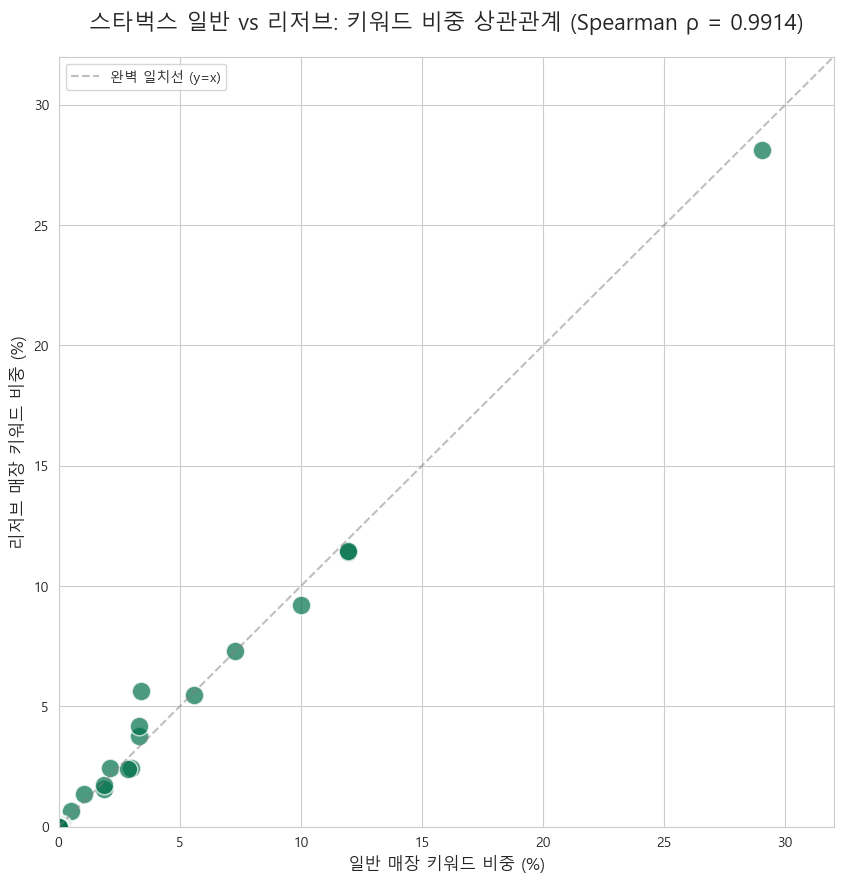

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 윈도우 한글 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 모든 키워드에 대해 비중(%) 계산
gen_ratio_all = (gen_keyword_sums / gen_total_mentions) * 100
res_ratio_all = (res_keyword_sums / res_total_mentions) * 100

ratio_df = pd.DataFrame({
    '일반 매장 비중(%)': gen_ratio_all,
    '리저브 매장 비중(%)': res_ratio_all
})

# 3. 산점도 그리기
plt.figure(figsize=(10, 10))

# 45도 가이드라인 (완벽 일치선)
plt.plot([0, 32], [0, 32], color='gray', linestyle='--', alpha=0.5, label='완벽 일치선 (y=x)')

# 실제 데이터 점 찍기
sns.scatterplot(x='일반 매장 비중(%)', y='리저브 매장 비중(%)', data=ratio_df, 
                s=180, color='#00704A', alpha=0.7, edgecolor='white')

# 그래프 꾸미기
plt.title(f'스타벅스 일반 vs 리저브: 키워드 비중 상관관계 (Spearman ρ = {correlation:.4f})', fontsize=16, pad=20)
plt.xlabel('일반 매장 키워드 비중 (%)', fontsize=12)
plt.ylabel('리저브 매장 키워드 비중 (%)', fontsize=12)
plt.xlim(0, 32)
plt.ylim(0, 32)

# [수정 포인트] 주요 키워드 이름 표시 및 겹침 방지
top5_names = gen_top5.index
for txt in ratio_df.index:
    if txt in top5_names:
        label = keyword_kr.get(txt, txt)
        x = ratio_df.loc[txt, '일반 매장 비중(%)']
        y = ratio_df.loc[txt, '리저브 매장 비중(%)']
        
        # 기본 위치 (오른쪽 위)
        xytext = (10, 10)
        
        # 값이 거의 똑같은 두 항목의 텍스트 위치 분산
        if label == '음료가 맛있어요':
            xytext = (10, -20)  # 점의 오른쪽 아래로 내림
        elif label == '친절해요':
            xytext = (10, 15)   # 점의

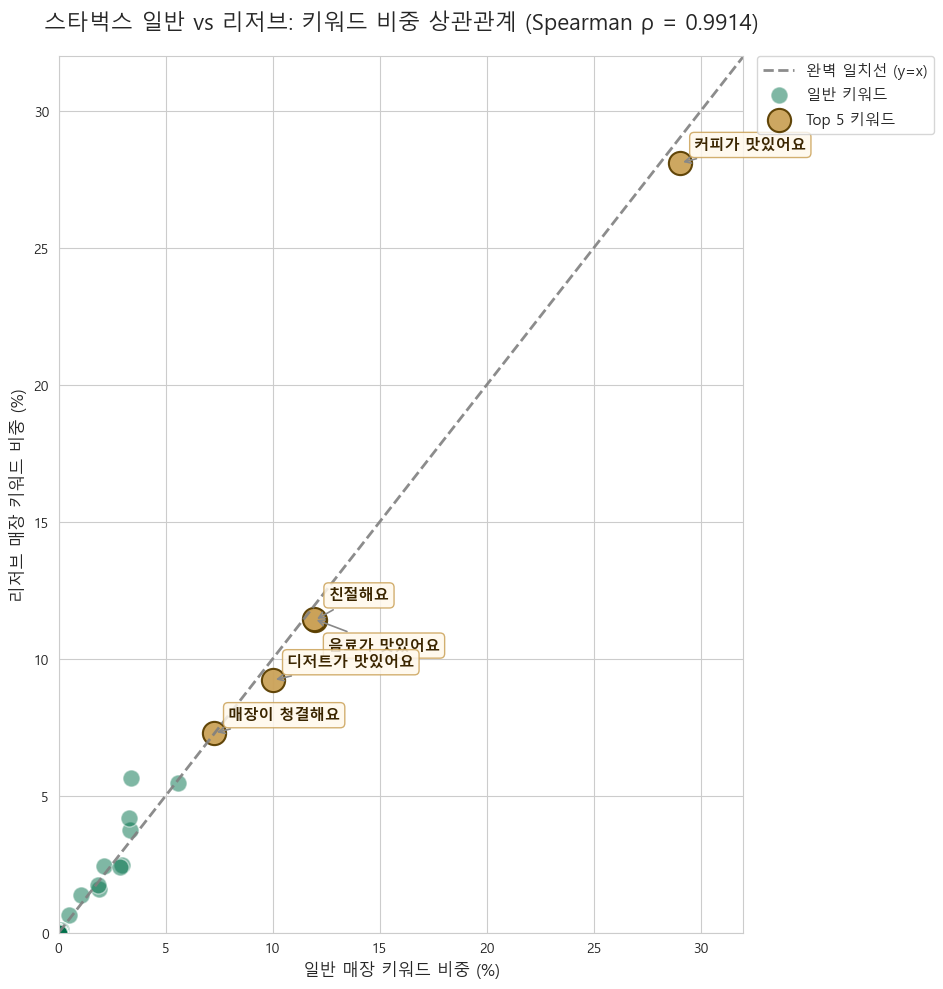

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

gen_ratio_all = (gen_keyword_sums / gen_total_mentions) * 100
res_ratio_all = (res_keyword_sums / res_total_mentions) * 100

ratio_df = pd.DataFrame({
    '일반 매장 비중(%)': gen_ratio_all,
    '리저브 매장 비중(%)': res_ratio_all
})

plt.figure(figsize=(11, 10))

# ① 완벽 일치선 — 더 진하게 (alpha 0.5 → 0.9, linewidth 추가)
plt.plot([0, 32], [0, 32], color='gray', linestyle='--', linewidth=2,
         alpha=0.9, label='완벽 일치선 (y=x)')

# ② 일반 점 (top5 아닌 것)
top5_names = gen_top5.index
mask_others = ~ratio_df.index.isin(top5_names)
sns.scatterplot(
    x='일반 매장 비중(%)', y='리저브 매장 비중(%)',
    data=ratio_df[mask_others],
    s=150, color='#00704A', alpha=0.5, edgecolor='white', label='일반 키워드'
)

# ③ top5 점 — 별도 색·크기·테두리로 강조
sns.scatterplot(
    x='일반 매장 비중(%)', y='리저브 매장 비중(%)',
    data=ratio_df[ratio_df.index.isin(top5_names)],
    s=280, color='#CBA258', alpha=0.95, edgecolor='#5a3e00', linewidth=1.5,
    label='Top 5 키워드'
)

# ④ top5 키워드 이름 표시 (겹침 방지 오프셋 포함)
offset_map = {
    '음료가 맛있어요': (10, -22),
    '친절해요':        (10,  15),
}

for txt in ratio_df.index:
    if txt in top5_names:
        label = keyword_kr.get(txt, txt)
        x = ratio_df.loc[txt, '일반 매장 비중(%)']
        y = ratio_df.loc[txt, '리저브 매장 비중(%)']
        xytext = offset_map.get(label, (10, 10))

        plt.annotate(
            label,
            xy=(x, y), xytext=xytext,
            textcoords='offset points',
            fontsize=11, fontweight='bold', color='#3a2500',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', fc='#fff8ec', ec='#CBA258', alpha=0.85)
        )

plt.title(
    f'스타벅스 일반 vs 리저브: 키워드 비중 상관관계 (Spearman ρ = {correlation:.4f})',
    fontsize=16, pad=20
)
plt.xlabel('일반 매장 키워드 비중 (%)', fontsize=12)
plt.ylabel('리저브 매장 키워드 비중 (%)', fontsize=12)
plt.xlim(0, 32)
plt.ylim(0, 32)

# ⑤ 범례 그래프 오른쪽 바깥으로
plt.legend(
    fontsize=11,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True
)
plt.tight_layout(rect=[0, 0, 0.87, 1])   # 오른쪽 여백 확보
plt.show()


### 결론 2
- 전체 키워드의 순위 상관계수가 0.9908로 두 집단의 만족도 우선순위가 사실상 동일함을 의미
- 유의확률(p<0.05) 역시 극도로 낮아, 이러한 일치성이 우연이 아님이 입증
- 이러한 결과는 모든 점들이 일직선 상에 모여있는 그래프에서도 확인 가능

절대 수치가 아닌 비중으로 비교했기 때문에 표본 수 차이가 결과에 영향을 미치지 않는다

### 최종 결론
- 리저브 매장과 일반 매장 간 소비자 인식 차이를 검증하기 위해 단계적으로 분석을 진행

- (H02-1)먼저 각 매장 유형별 Top5 키워드 비중을 직접 비교한 결과, 두 집단의 상위 키워드 구성이 완전히 일치했으며 비중 차이도 최대 0.94%p로 1%p 미만에 불과. 
- 카이제곱 검정상 P-value는 낮게 나타났으나, 이는 방대한 데이터 양에 의한 결과일 뿐 효과 크기 분석을 통해 실질적인 차이가 '무시할 수준'임을 증명함.

- (H02-2)단순히 상위 5개만 비슷한 것일 수 있다는 가능성을 배제하기 위해 전체 키워드의 순위 구조를 스피어만 상관분석으로 검증 -> 그 결과 상관계수가 0.99로 두 집단의 키워드 우선순위가 사실상 동일함이 확인


#### 즉, 리저브 매장은 프리미엄을 내세우고 있음에도 불구하고, 소비자 인식에서는 일반 매장과 뚜렷한 차별화를 이루지 못함.